# EDA: Why `machine_failure_data.csv` Cannot Support State Prediction or Binary Classification

This notebook documents the five compounding problems that make this dataset unusable for either a temporal LSTM or a binary failure classifier.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('../data/raw_data/machine_failure_data.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
FEATURES = ['Temperature', 'Pressure', 'Vibration_Level', 'Humidity', 'Power_Consumption']

print(f'Shape: {df.shape}')
df.head()

Shape: (3000, 8)


,Machine_ID,Timestamp,Temperature,Pressure,Vibration_Level,Humidity,Power_Consumption,Failure_Status
0,MACHINE_001,2025-01-01 00:00:00,56.23,106.00,3.75,77.50,92.06,0
1,MACHINE_002,2025-01-01 00:10:00,36.45,179.39,8.02,74.75,30.30,0
2,MACHINE_003,2025-01-01 00:20:00,64.44,432.66,4.38,62.55,38.74,0
3,MACHINE_004,2025-01-01 00:30:00,23.28,407.56,4.77,38.96,58.70,0
4,MACHINE_005,2025-01-01 00:40:00,27.35,197.15,8.81,50.49,35.34,1


---
## Problem 1 — No Time Series (1 Row Per Machine)

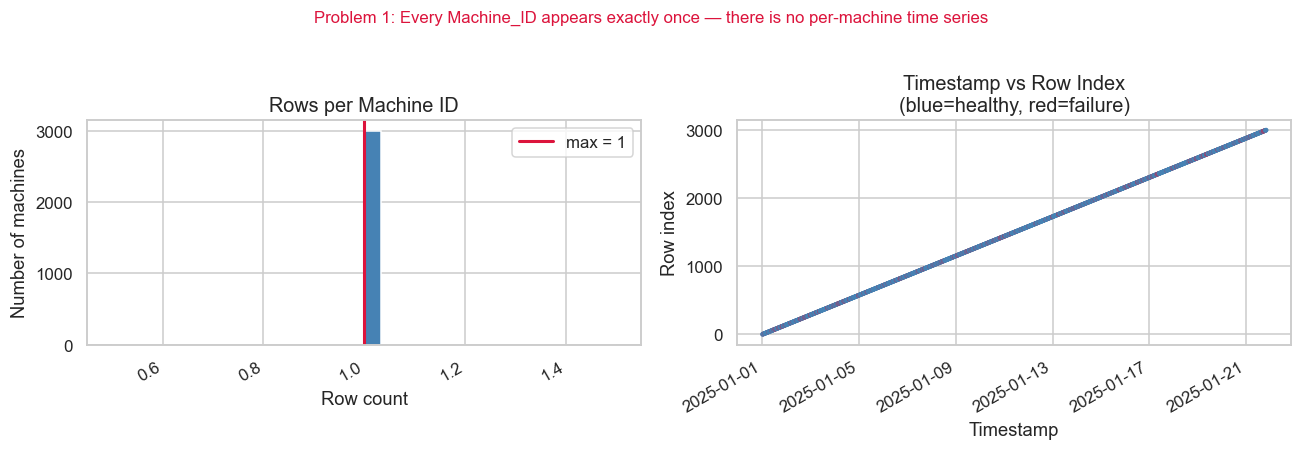

Unique Machine IDs : 3000
Total rows         : 3000
Rows per machine   : min=1  max=1  mean=1.0
=> Each row is a different machine. Nothing to sequence over.


In [2]:
rows_per_machine = df.groupby('Machine_ID').size()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram of rows per machine
axes[0].hist(rows_per_machine, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Rows per Machine ID', fontsize=13)
axes[0].set_xlabel('Row count')
axes[0].set_ylabel('Number of machines')
axes[0].axvline(1, color='crimson', linewidth=2, label='max = 1')
axes[0].legend()

# Right: timeline — scatter of timestamps, coloured by failure
colors = df['Failure_Status'].map({0: 'steelblue', 1: 'crimson'})
axes[1].scatter(df['Timestamp'], df.index, c=colors, s=4, alpha=0.6)
axes[1].set_title('Timestamp vs Row Index\n(blue=healthy, red=failure)', fontsize=13)
axes[1].set_xlabel('Timestamp')
axes[1].set_ylabel('Row index')
fig.autofmt_xdate(rotation=30)

plt.suptitle('Problem 1: Every Machine_ID appears exactly once — there is no per-machine time series',
             fontsize=11, color='crimson', y=1.02)
plt.tight_layout()
plt.show()

print(f'Unique Machine IDs : {df["Machine_ID"].nunique()}')
print(f'Total rows         : {len(df)}')
print(f'Rows per machine   : min={rows_per_machine.min()}  max={rows_per_machine.max()}  mean={rows_per_machine.mean():.1f}')
print('=> Each row is a different machine. Nothing to sequence over.')

---
## Problem 2 — Labels Are Independent of Features

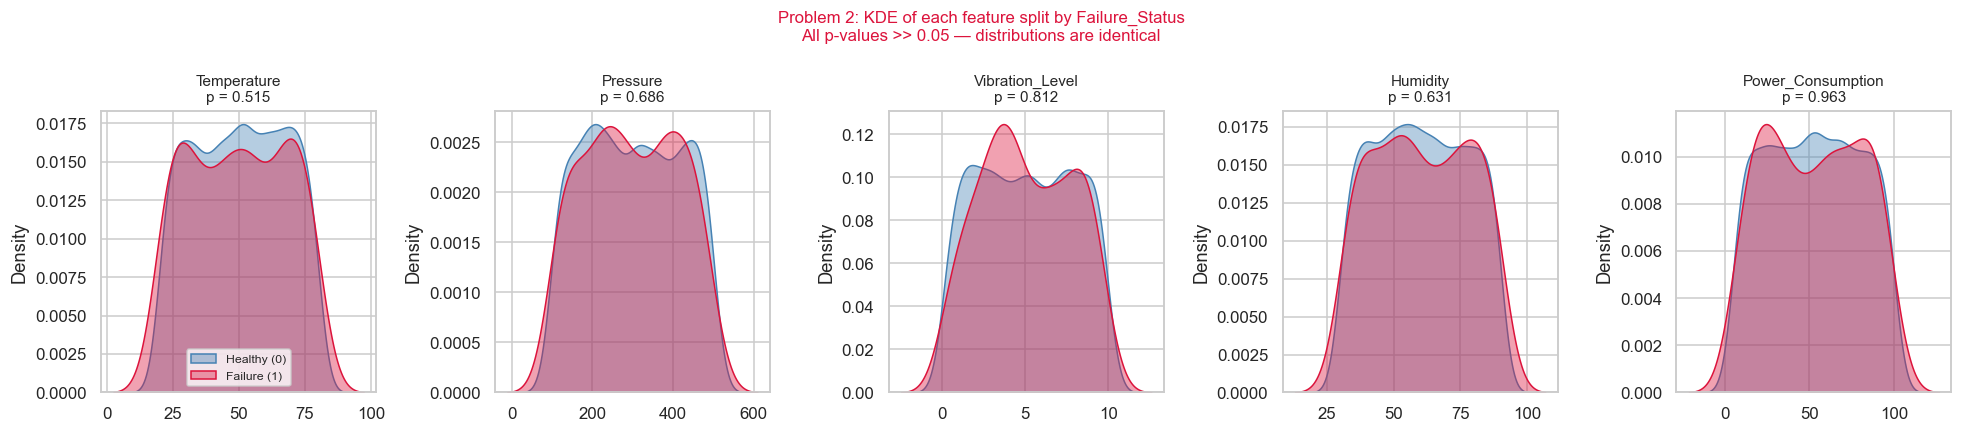

t-test p-values (failure vs healthy):
  Temperature            p=0.515  not significant
  Pressure               p=0.686  not significant
  Vibration_Level        p=0.812  not significant
  Humidity               p=0.631  not significant
  Power_Consumption      p=0.963  not significant


In [3]:
fig, axes = plt.subplots(1, len(FEATURES), figsize=(18, 4), sharey=False)

p_values = []
for ax, feat in zip(axes, FEATURES):
    g0 = df[df['Failure_Status'] == 0][feat]
    g1 = df[df['Failure_Status'] == 1][feat]
    _, p = stats.ttest_ind(g0, g1)
    p_values.append(p)

    sns.kdeplot(g0, ax=ax, label='Healthy (0)', fill=True, alpha=0.4, color='steelblue')
    sns.kdeplot(g1, ax=ax, label='Failure (1)', fill=True, alpha=0.4, color='crimson')
    ax.set_title(f'{feat}\np = {p:.3f}', fontsize=10)
    ax.set_xlabel('')
    if feat == FEATURES[0]:
        ax.legend(fontsize=8)
    else:
        ax.get_legend() and ax.get_legend().remove()

plt.suptitle('Problem 2: KDE of each feature split by Failure_Status\n'
             'All p-values >> 0.05 — distributions are identical',
             fontsize=11, color='crimson')
plt.tight_layout()
plt.show()

print('t-test p-values (failure vs healthy):')
for feat, p in zip(FEATURES, p_values):
    sig = 'SIGNIFICANT' if p < 0.05 else 'not significant'
    print(f'  {feat:22s} p={p:.3f}  {sig}')

### Pairplot: no separation in 2D either

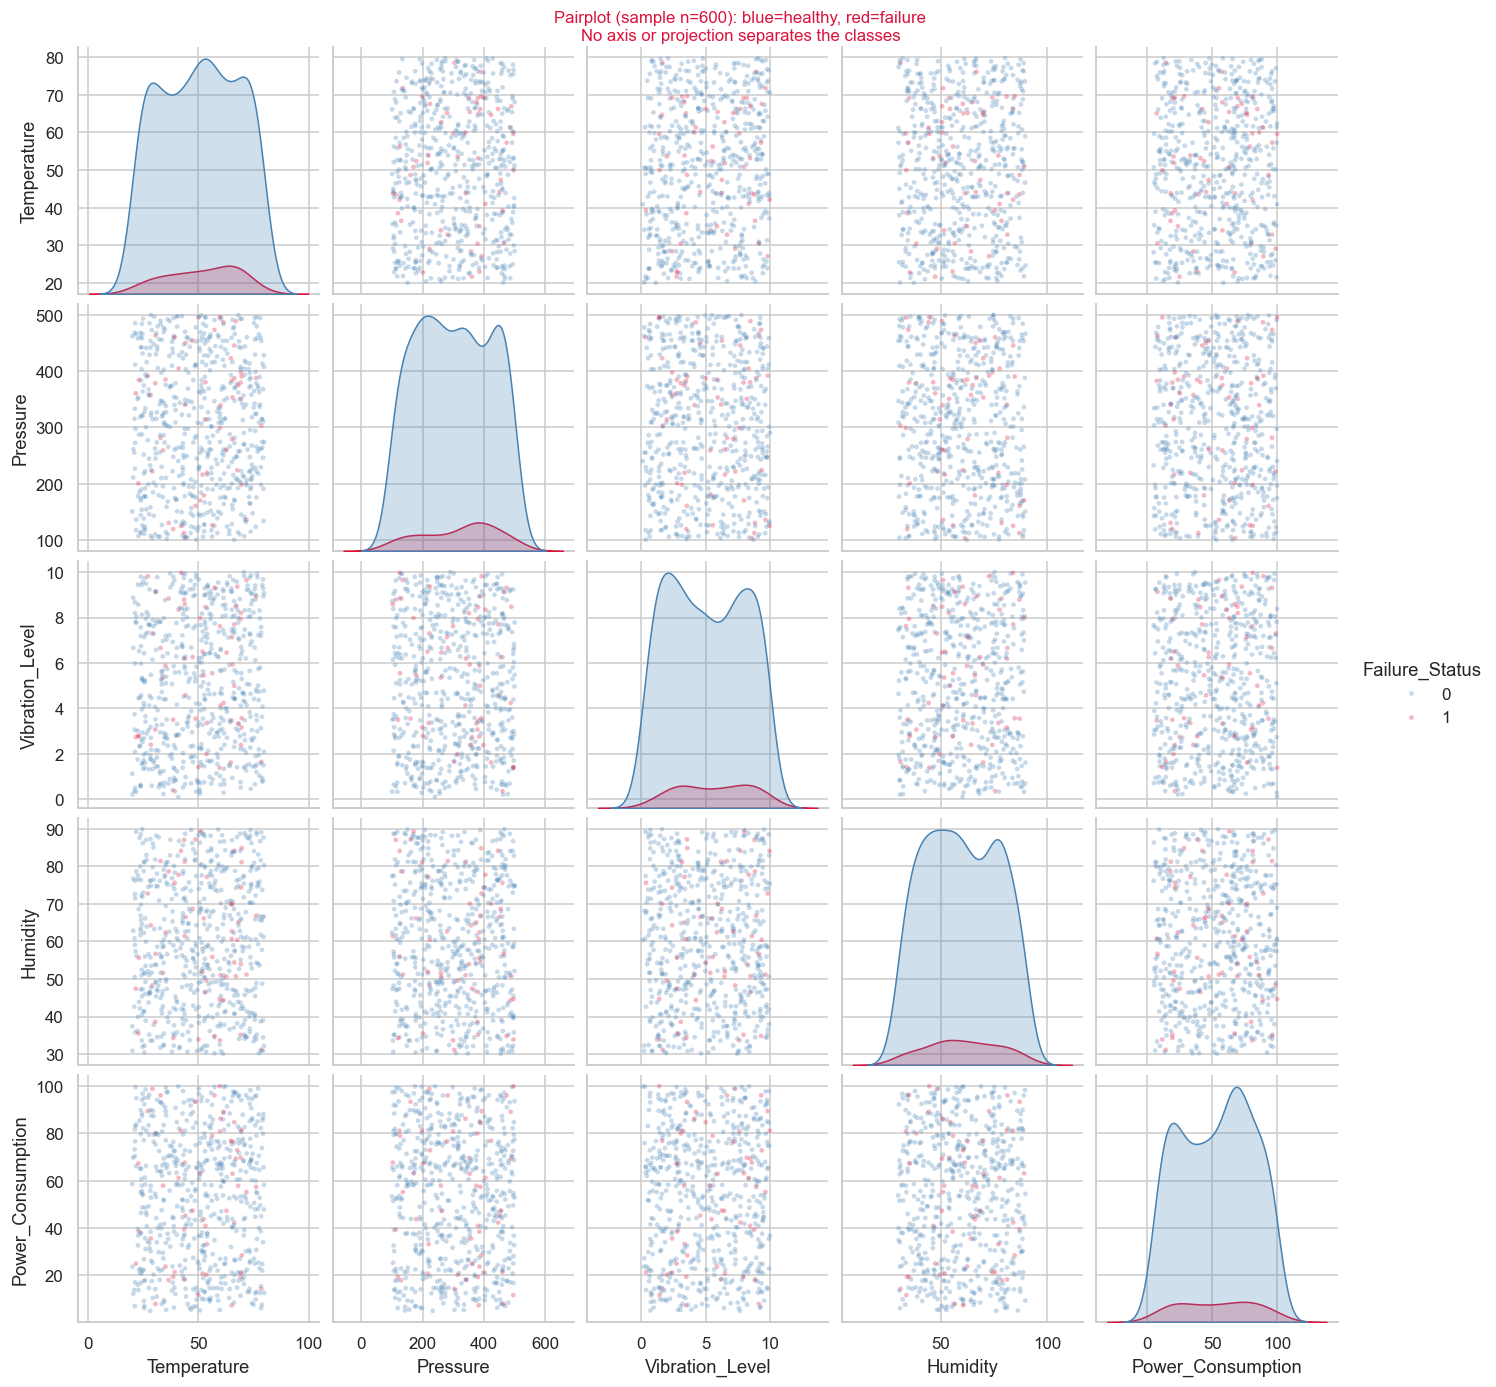

In [4]:
sample = df.sample(600, random_state=42)
g = sns.pairplot(
    sample[FEATURES + ['Failure_Status']],
    hue='Failure_Status',
    palette={0: 'steelblue', 1: 'crimson'},
    plot_kws={'alpha': 0.3, 's': 10},
    diag_kind='kde'
)
g.figure.suptitle('Pairplot (sample n=600): blue=healthy, red=failure\n'
                  'No axis or projection separates the classes',
                  y=1.01, fontsize=11, color='crimson')
plt.show()

### PCA: classes overlap completely in the principal components

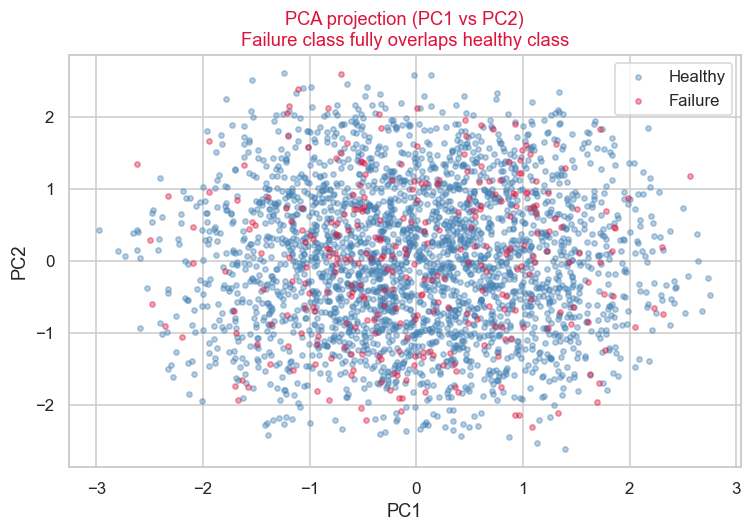

In [5]:
X = StandardScaler().fit_transform(df[FEATURES])
pcs = PCA(n_components=2).fit_transform(X)

fig, ax = plt.subplots(figsize=(7, 5))
for label, color, name in [(0, 'steelblue', 'Healthy'), (1, 'crimson', 'Failure')]:
    mask = df['Failure_Status'] == label
    ax.scatter(pcs[mask, 0], pcs[mask, 1], c=color, label=name, alpha=0.4, s=12)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA projection (PC1 vs PC2)\nFailure class fully overlaps healthy class', color='crimson')
ax.legend()
plt.tight_layout()
plt.show()

---
## Problem 3 — Binary Classifiers Perform Worse Than Guessing

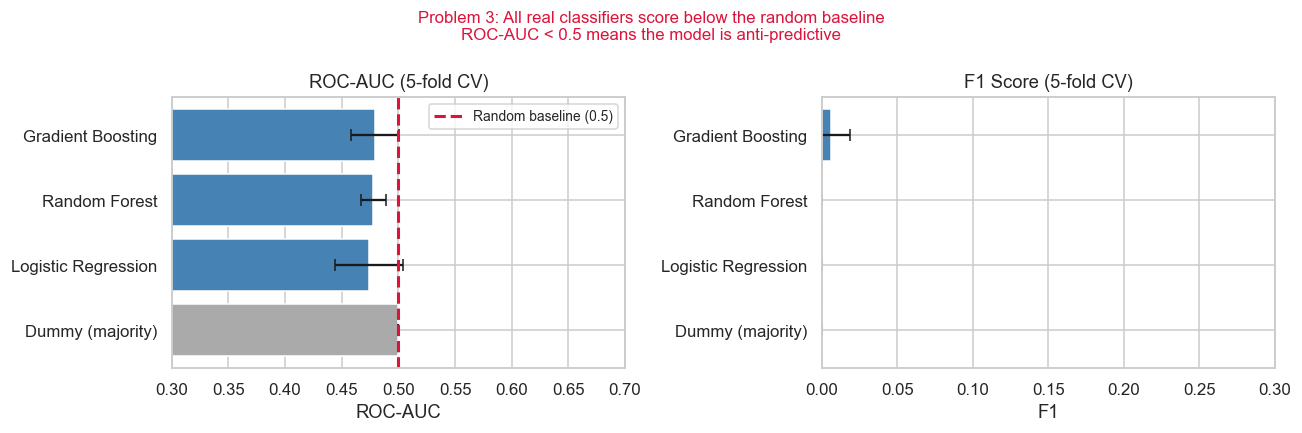

              Model  ROC-AUC mean  ROC-AUC std  F1 mean   F1 std
   Dummy (majority)      0.500000     0.000000 0.000000 0.000000
Logistic Regression      0.474057     0.030080 0.000000 0.000000
      Random Forest      0.477824     0.010829 0.000000 0.000000
  Gradient Boosting      0.479390     0.021305 0.006154 0.012308


In [6]:
X_scaled = StandardScaler().fit_transform(df[FEATURES])
y = df['Failure_Status'].values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_specs = [
    ('Dummy (majority)', DummyClassifier(strategy='most_frequent')),
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(n_estimators=100, random_state=42)),
]

results = []
for name, model in model_specs:
    roc = cross_val_score(model, X_scaled, y, cv=cv, scoring='roc_auc')
    f1  = cross_val_score(model, X_scaled, y, cv=cv, scoring='f1')
    results.append({'Model': name, 'ROC-AUC mean': roc.mean(), 'ROC-AUC std': roc.std(),
                    'F1 mean': f1.mean(), 'F1 std': f1.std()})

res_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#aaaaaa' if 'Dummy' in m else 'steelblue' for m in res_df['Model']]
bars = axes[0].barh(res_df['Model'], res_df['ROC-AUC mean'], xerr=res_df['ROC-AUC std'],
                    color=colors, capsize=4)
axes[0].axvline(0.5, color='crimson', linewidth=2, linestyle='--', label='Random baseline (0.5)')
axes[0].set_xlim(0.3, 0.7)
axes[0].set_title('ROC-AUC (5-fold CV)', fontsize=12)
axes[0].set_xlabel('ROC-AUC')
axes[0].legend(fontsize=9)

bars2 = axes[1].barh(res_df['Model'], res_df['F1 mean'], xerr=res_df['F1 std'],
                     color=colors, capsize=4)
axes[1].set_xlim(0, 0.3)
axes[1].set_title('F1 Score (5-fold CV)', fontsize=12)
axes[1].set_xlabel('F1')

plt.suptitle('Problem 3: All real classifiers score below the random baseline\n'
             'ROC-AUC < 0.5 means the model is anti-predictive',
             fontsize=11, color='crimson')
plt.tight_layout()
plt.show()

print(res_df.to_string(index=False))

### Random Forest feature importances — perfectly uniform = random noise

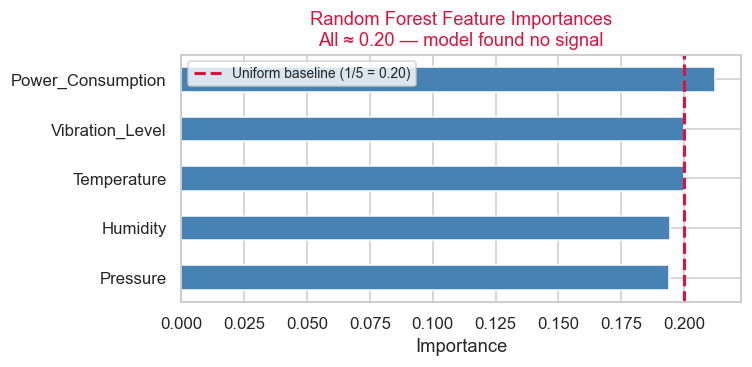

In [7]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_scaled, y)
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(7, 3.5))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(1/len(FEATURES), color='crimson', linestyle='--', linewidth=2,
           label=f'Uniform baseline (1/{len(FEATURES)} = {1/len(FEATURES):.2f})')
ax.set_title('Random Forest Feature Importances\nAll ≈ 0.20 — model found no signal', color='crimson')
ax.set_xlabel('Importance')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## Problem 4 — Failure Events Are Not Temporally Clustered

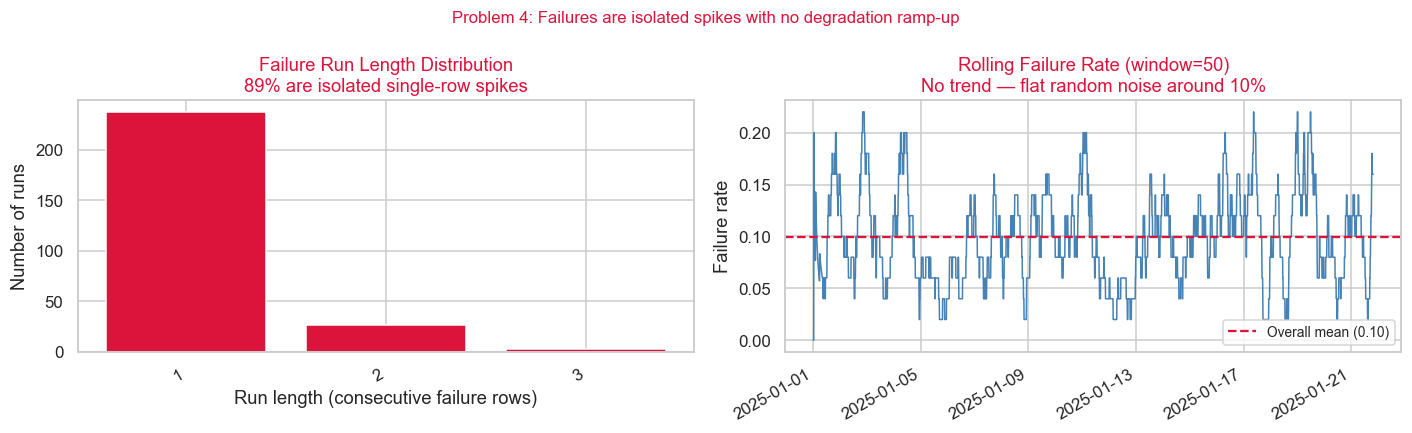

Isolated failure runs (length=1): 237 / 266 = 89%


In [8]:
df_sorted = df.sort_values('Timestamp').reset_index(drop=True)
runs = (df_sorted['Failure_Status'] != df_sorted['Failure_Status'].shift()).cumsum()
failure_run_lengths = df_sorted[df_sorted['Failure_Status'] == 1].groupby(runs)['Failure_Status'].count()
run_counts = failure_run_lengths.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: failure run length distribution
axes[0].bar(run_counts.index, run_counts.values, color='crimson', edgecolor='white')
axes[0].set_xlabel('Run length (consecutive failure rows)')
axes[0].set_ylabel('Number of runs')
axes[0].set_title('Failure Run Length Distribution\n89% are isolated single-row spikes', color='crimson')
axes[0].set_xticks(run_counts.index)

# Right: rolling failure rate over time
df_sorted['failure_roll'] = df_sorted['Failure_Status'].rolling(50, min_periods=1).mean()
axes[1].plot(df_sorted['Timestamp'], df_sorted['failure_roll'], color='steelblue', linewidth=1)
axes[1].axhline(df['Failure_Status'].mean(), color='crimson', linestyle='--',
                label=f'Overall mean ({df["Failure_Status"].mean():.2f})')
axes[1].set_title('Rolling Failure Rate (window=50)\nNo trend — flat random noise around 10%', color='crimson')
axes[1].set_ylabel('Failure rate')
axes[1].legend(fontsize=9)
fig.autofmt_xdate(rotation=30)

plt.suptitle('Problem 4: Failures are isolated spikes with no degradation ramp-up', fontsize=11, color='crimson')
plt.tight_layout()
plt.show()

print(f'Isolated failure runs (length=1): {(failure_run_lengths==1).sum()} / {len(failure_run_lengths)} = '
      f'{(failure_run_lengths==1).mean():.0%}')

---
## Problem 5 — No Temporal Autocorrelation

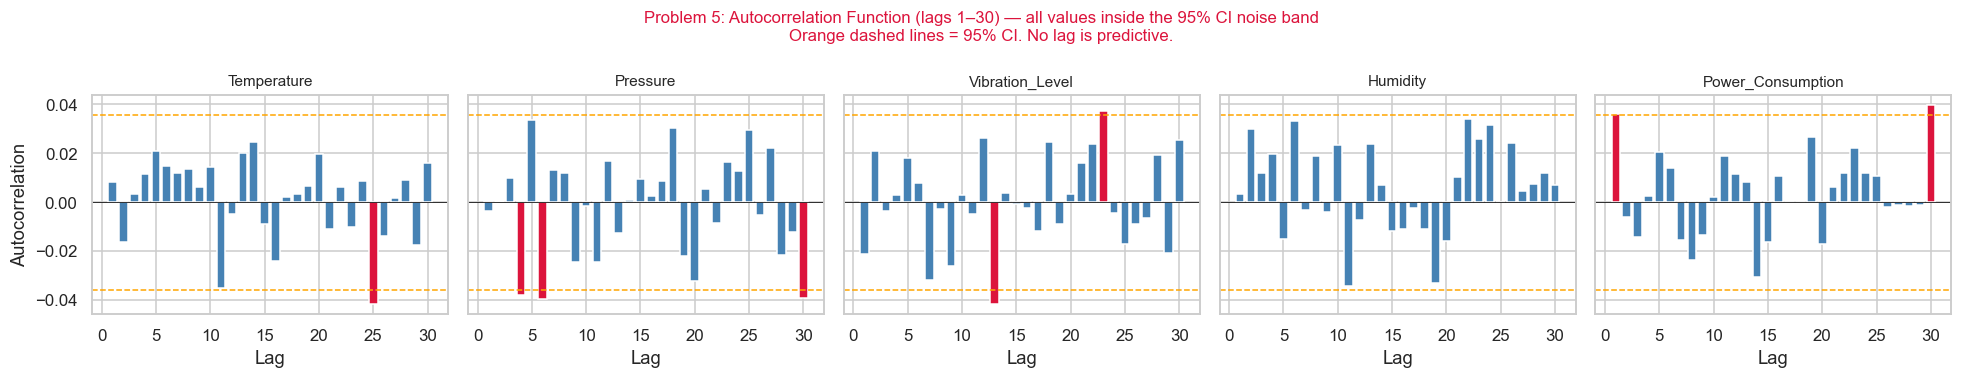

Lag-1 autocorrelations:
  Temperature           : 0.0084
  Pressure              : -0.0036
  Vibration_Level       : -0.0214
  Humidity              : 0.0032
  Power_Consumption     : 0.0362


In [9]:
max_lags = 30
fig, axes = plt.subplots(1, len(FEATURES), figsize=(18, 3.5), sharey=True)

for ax, feat in zip(axes, FEATURES):
    series = df_sorted[feat].values
    acf_vals = [pd.Series(series).autocorr(lag=k) for k in range(1, max_lags + 1)]
    ax.bar(range(1, max_lags + 1), acf_vals,
           color=['crimson' if abs(v) > 1.96/np.sqrt(len(series)) else 'steelblue' for v in acf_vals])
    # 95% CI bands
    ci = 1.96 / np.sqrt(len(series))
    ax.axhline(ci, color='orange', linestyle='--', linewidth=1)
    ax.axhline(-ci, color='orange', linestyle='--', linewidth=1)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('Lag')
    if feat == FEATURES[0]:
        ax.set_ylabel('Autocorrelation')

plt.suptitle('Problem 5: Autocorrelation Function (lags 1–30) — all values inside the 95% CI noise band\n'
             'Orange dashed lines = 95% CI. No lag is predictive.',
             fontsize=11, color='crimson')
plt.tight_layout()
plt.show()

print('Lag-1 autocorrelations:')
for feat in FEATURES:
    ac = df_sorted[feat].autocorr(lag=1)
    print(f'  {feat:22s}: {ac:.4f}')

---
## Summary

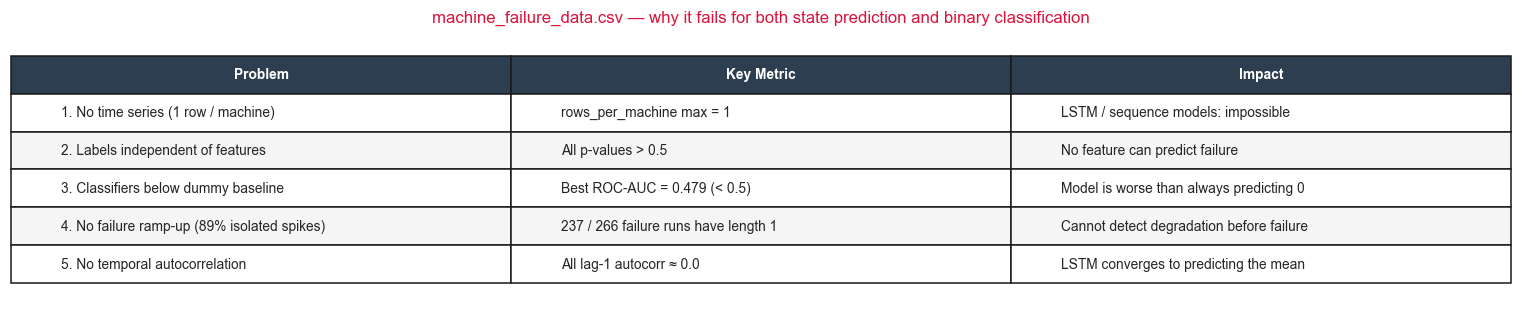

Root cause: rows were generated by independently sampling from a fixed distribution.
Failure_Status was assigned with a flat ~10% probability, uncoupled from sensor values.
There is no physical continuity between any two consecutive rows.


In [10]:
summary = {
    'Problem': [
        '1. No time series (1 row / machine)',
        '2. Labels independent of features',
        '3. Classifiers below dummy baseline',
        '4. No failure ramp-up (89% isolated spikes)',
        '5. No temporal autocorrelation',
    ],
    'Key Metric': [
        'rows_per_machine max = 1',
        'All p-values > 0.5',
        'Best ROC-AUC = 0.479 (< 0.5)',
        '237 / 266 failure runs have length 1',
        'All lag-1 autocorr ≈ 0.0',
    ],
    'Impact': [
        'LSTM / sequence models: impossible',
        'No feature can predict failure',
        'Model is worse than always predicting 0',
        'Cannot detect degradation before failure',
        'LSTM converges to predicting the mean',
    ]
}

fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')
t = ax.table(
    cellText=[[summary['Problem'][i], summary['Key Metric'][i], summary['Impact'][i]]
              for i in range(5)],
    colLabels=['Problem', 'Key Metric', 'Impact'],
    cellLoc='left', loc='center'
)
t.auto_set_font_size(False)
t.set_fontsize(9)
t.scale(1, 2)
for (row, col), cell in t.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f5f5f5')
plt.title('machine_failure_data.csv — why it fails for both state prediction and binary classification',
          fontsize=11, color='crimson', pad=10)
plt.tight_layout()
plt.show()

print('Root cause: rows were generated by independently sampling from a fixed distribution.')
print('Failure_Status was assigned with a flat ~10% probability, uncoupled from sensor values.')
print('There is no physical continuity between any two consecutive rows.')